# R&D IA : Outil d'Analyse et de Détection d'Anomalies sur Images Thermiques de Charges Utiles Satellitaires

Les caméras infrarouges embarquées sur les satellites transmettent régulièrement des images de calibration. Ce notebook implémente un outil complet de :
1. **Simulation de Flux Optique (OpenCV) :** Génération d'images thermiques de calibration intégrant du bruit photonique, des pixels défectueux (*hot pixels*) et des gradients de surchauffe locale.
2. **Extraction de Caractéristiques Topologiques :** Segmentation et isolation des régions suspectes via des opérations de morphologie mathématique.
3. **Classification et Diagnostic IA (Scikit-Learn) :** Utilisation d'un modèle non-supervisé pour classifier automatiquement la sévérité des anomalies détectées.

---

In [ ]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Environnement initialisé.")

Environnement initialisé.


## 1. Module Vision : Générateur d'Images Thermiques et Pipeline de Segmentation OpenCV
Nous simulons le comportement d'un détecteur infrarouge soumis à des contraintes thermiques spatiales. Le pipeline OpenCV extrait les propriétés géométriques (surface, circularité, intensité maximale) de chaque zone isolée.

In [ ]:
def generate_thermal_image(size=128, hot_pixels=False, gradient_anomaly=False, noise_level=3):
    """Génère une image thermique synthétique d'un détecteur de caméra spatiale."""
    img = np.zeros((size, size), dtype=np.float32)
    cx, cy = size // 2, size // 2
    for i in range(size):
        for j in range(size):
            dist = np.sqrt((i - cy)**2 + (j - cx)**2)
            img[i, j] = 200 - dist * 0.8  # Température de base (Kelvin-like)

    # Bruit électronique du capteur
    img += np.random.normal(0, noise_level, (size, size)).astype(np.float32)

    if hot_pixels:
        # Défauts de matrice (Pixels chauds permanents)
        n_hot = np.random.randint(5, 15)
        px = np.random.randint(10, size-10, n_hot)
        py = np.random.randint(10, size-10, n_hot)
        img[px, py] += np.random.uniform(40, 70, n_hot)

    if gradient_anomaly:
        # Surchauffe locale d'un composant électronique adjacent
        ax, ay = np.random.randint(30, size-30, 2)
        for i in range(size):
            for j in range(size):
                d = np.sqrt((i-ax)**2 + (j-ay)**2)
                if d < 15:
                    img[i, j] += 30 * np.exp(-d**2 / 50)

    img = gaussian_filter(img, sigma=0.8)
    return np.clip(img, 0, 255).astype(np.uint8)

def extract_region_features(img, threshold_sigma=2.2):
    """Pipeline OpenCV pour isoler les régions et en extraire des caractéristiques pour l'IA."""
    mean_val, std_val = np.mean(img), np.std(img)
    threshold = mean_val + threshold_sigma * std_val

    # Masque binaire des zones chaudes
    hot_mask = (img > threshold).astype(np.uint8) * 255
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    hot_mask = cv2.morphologyEx(hot_mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(hot_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    regions_features = []
    for c in contours:
        area = cv2.contourArea(c)
        if area > 1: # Filtre pour éliminer le bruit infime
            x, y, w, h = cv2.boundingRect(c)
            max_temp = float(img[y:y+h, x:x+w].max())
            mean_temp = float(img[y:y+h, x:x+w].mean())
            perimeter = cv2.arcLength(c, True)
            circularity = (4 * np.pi * area) / (perimeter**2) if perimeter > 0 else 0

            regions_features.append({
                'area': area,
                'max_temp': max_temp,
                'mean_temp': mean_temp,
                'circularity': circularity,
                'bbox': (x, y, w, h)
            })

    return hot_mask, regions_features, threshold

print("Fonctions de traitement d'images bien configurées.")

Fonctions de traitement d'images bien configurées.


### Visualisation 1 : Tableau de Bord d'Analyse d'Images Thermiques
Afficisons les résultats du traitement sur nos différents cas d'études (Nominal, Hot Pixels, Surchauffe, Multi-anomalies) avec leurs histogrammes associés.

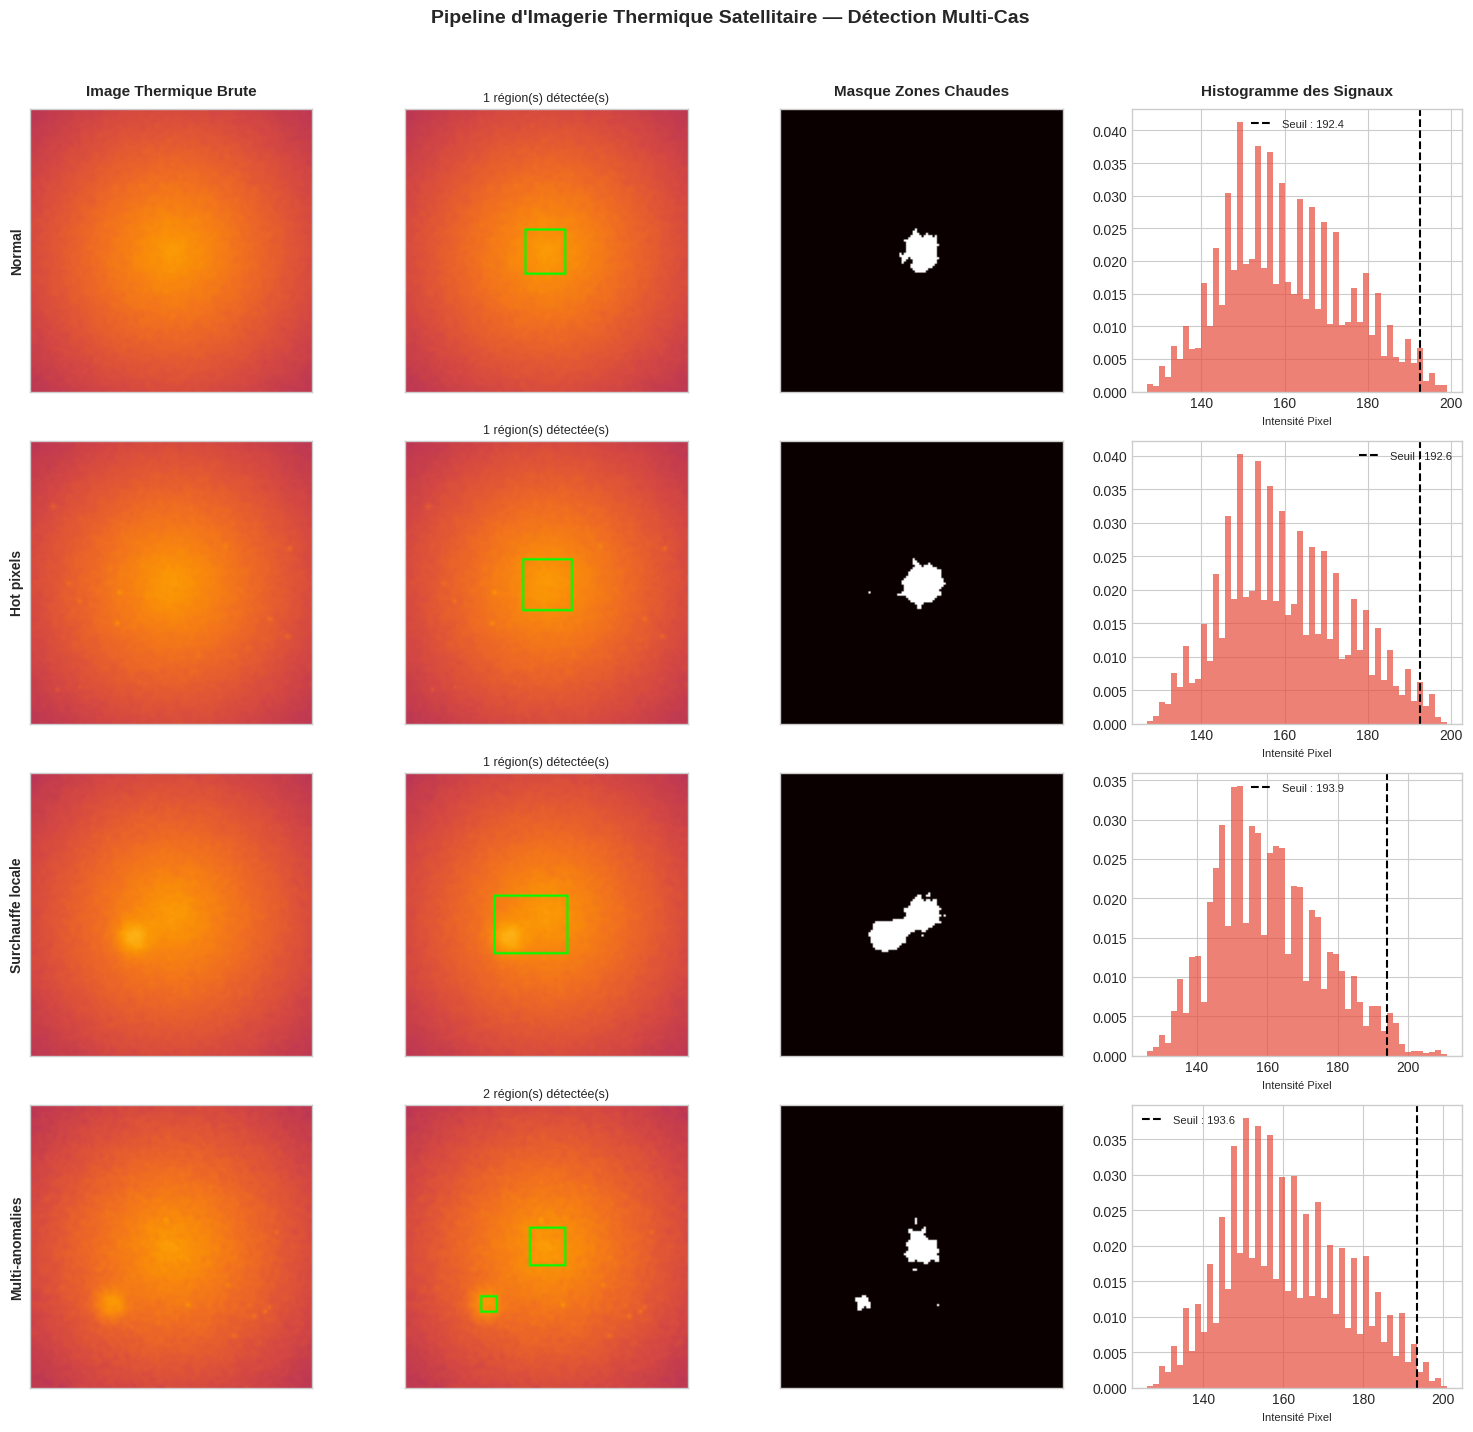

In [ ]:
cases = [
    ('Normal',             generate_thermal_image()),
    ('Hot pixels',         generate_thermal_image(hot_pixels=True)),
    ('Surchauffe locale',  generate_thermal_image(gradient_anomaly=True)),
    ('Multi-anomalies',    generate_thermal_image(hot_pixels=True, gradient_anomaly=True, noise_level=4)),
]

fig, axes = plt.subplots(4, 4, figsize=(15, 14))
col_titles = ['Image Thermique Brute', 'Anomalies Annotées', 'Masque Zones Chaudes', 'Histogramme des Signaux']

for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)

for row, (name, img) in enumerate(cases):
    mask, regions, thresh = extract_region_features(img)

    # Image originale convertie en RGB Inferno
    orig_rgb = cv2.cvtColor(cv2.applyColorMap(img, cv2.COLORMAP_INFERNO), cv2.COLOR_BGR2RGB)
    annotated = orig_rgb.copy()

    # Dessin des bounding boxes OpenCV sur l'image annotée
    for r in regions:
        x, y, w, h = r['bbox']
        cv2.rectangle(annotated, (x, y), (x+w, y+h), (0, 255, 0), 1)

    axes[row, 0].imshow(orig_rgb)
    axes[row, 0].set_ylabel(name, fontsize=10, fontweight='bold')

    axes[row, 1].imshow(annotated)
    axes[row, 1].set_title(f'{len(regions)} région(s) détectée(s)', fontsize=9)

    axes[row, 2].imshow(mask, cmap='hot')

    axes[row, 3].hist(img.ravel(), bins=50, color='#e74c3c', alpha=0.7, density=True)
    axes[row, 3].axvline(thresh, color='black', ls='--', lw=1.5, label=f'Seuil : {thresh:.1f}')
    axes[row, 3].legend(fontsize=8)
    axes[row, 3].set_xlabel('Intensité Pixel', fontsize=8)

    for ax in axes[row, :3]:
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("Pipeline d'Imagerie Thermique Satellitaire — Détection Multi-Cas", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2. Intégration de l'IA (Machine Learning Non-Supervisé)
Pour rendre notre outil opérationnel autonome, nous générons une base de données de régions extraites par OpenCV. Nous entraînons ensuite un algorithme d'**Isolation Forest** pour classer automatiquement les régions en deux catégories : fluctuation normale du bruit (Faux Positif) vs Véritable Anomalie thermique critique.

In [ ]:
# Génération d'une grande base de données de régions suspectes
dataset_regions = []
labels_terrain = [] # 0 pour faux positif (bruit), 1 pour vraie anomalie

print("Génération du dataset ...")
for _ in range(100):
    # Cas nominaux (génèrent des petites fausses détections à cause du bruit)
    img_nom = generate_thermal_image(noise_level=4)
    _, regions_nom, _ = extract_region_features(img_nom)
    for r in regions_nom:
        dataset_regions.append([r['area'], r['max_temp'], r['mean_temp'], r['circularity']])
        labels_terrain.append(0)

    # Cas avec anomalies réelles
    img_anom = generate_thermal_image(hot_pixels=True, gradient_anomaly=True, noise_level=3)
    _, regions_anom, _ = extract_region_features(img_anom)
    for r in regions_anom:
        dataset_regions.append([r['area'], r['max_temp'], r['mean_temp'], r['circularity']])
        # On définit une règle empirique pour la vérité terrain : si c'est grand ou très chaud, c'est une vraie anomalie
        if r['area'] > 5 or r['max_temp'] > 220:
            labels_terrain.append(1)
        else:
            labels_terrain.append(0)

df_features = pd.DataFrame(dataset_regions, columns=['area', 'max_temp', 'mean_temp', 'circularity'])

# Entraînement (avce Isolation Forest)
# On règle la contamination pour refléter la proportion attendue d'anomalies critiques
clf = IsolationForest(contamination=0.25, random_state=42)
preds = clf.fit_predict(df_features)

# Post-traitement des prédictions (-1 pour anomalie selon scikit-learn -> 1)
df_features['Pred_Class'] = [1 if p == -1 else 0 for p in preds]
df_features['True_Class'] = labels_terrain

print(f"Dataset prêt. Nombre total de régions analysées : {len(df_features)}")

Génération du dataset ...
Dataset prêt. Nombre total de régions analysées : 301


### Visualisation 3 : Évaluation de l'Outil IA
À cause du bruit de capteur élevé, certaines fluctuations statistiques imitent de petites anomalies de gradients thermiques. Analysons comment notre modèle se comporte face à ces incertitudes industrielles.

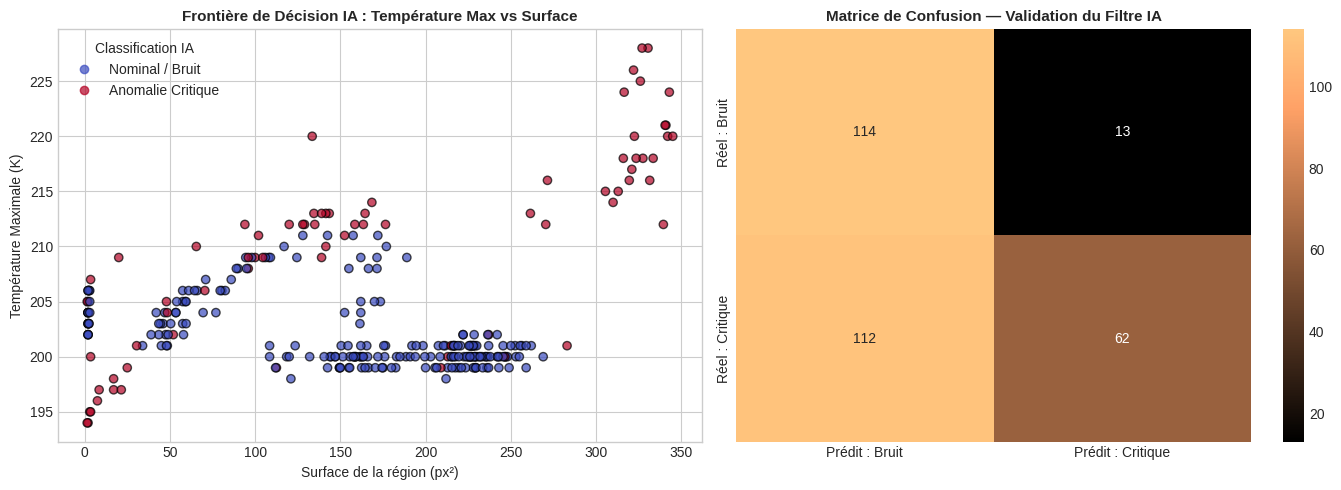


RAPPORT DE CLASSIFICATION DU SYSTÈME :
                   precision    recall  f1-score   support

    Bruit de Fond       0.50      0.90      0.65       127
Anomalie Critique       0.83      0.36      0.50       174

         accuracy                           0.58       301
        macro avg       0.67      0.63      0.57       301
     weighted avg       0.69      0.58      0.56       301



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Espace de caractéristiques : Visualisation des décisions du modèle IA
scatter = axes[0].scatter(df_features['area'], df_features['max_temp'],
                         c=df_features['Pred_Class'], cmap='coolwarm', alpha=0.7, edgecolors='k')
axes[0].set_title("Frontière de Décision IA : Température Max vs Surface", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Surface de la région (px²)")
axes[0].set_ylabel("Température Maximale (K)")
legend = axes[0].legend(*scatter.legend_elements(), title="Classification IA")
legend.get_texts()[0].set_text("Nominal / Bruit")
legend.get_texts()[1].set_text("Anomalie Critique")

# 2. Matrice de confusion
cm = confusion_matrix(df_features['True_Class'], df_features['Pred_Class'])
sns.heatmap(cm, annot=True, fmt='d', cmap='copper', ax=axes[1],
            xticklabels=["Prédit : Bruit", "Prédit : Critique"],
            yticklabels=["Réel : Bruit", "Réel : Critique"])
axes[1].set_title("Matrice de Confusion — Validation du Filtre IA", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nRAPPORT DE CLASSIFICATION DU SYSTÈME :")
print(classification_report(df_features['True_Class'], df_features['Pred_Class'],
                            target_names=["Bruit de Fond", "Anomalie Critique"]))

## 3. Visualisation Avancée : Diagnostic en Conditions de Vol Réelles
Pour conclure notre étude technique, nous simulons une nouvelle image de calibration fortement bruitée. L'outil OpenCV isole la zone et notre modèle d'IA prend la décision finale en calculant son indice de sévérité.

ANALYSE DU FLUX OPTIQUE EN TEMPS RÉEL :
  -> Région 1 qualifiée [CRITIQUE] : Surface=122px² · T_max=200.0K
  -> Région 2 qualifiée [CRITIQUE] : Surface=82px² · T_max=212.0K


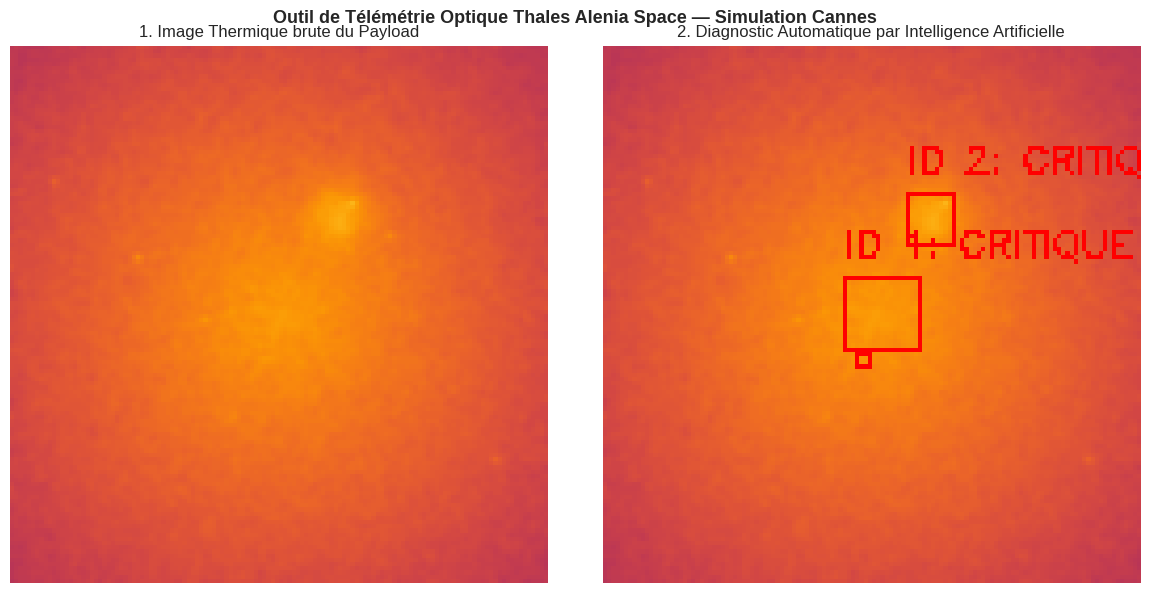

In [ ]:
# Génération d'une image test inédite
test_img = generate_thermal_image(hot_pixels=True, gradient_anomaly=True, noise_level=5)
mask, test_regions, _ = extract_region_features(test_img)

test_rgb = cv2.cvtColor(cv2.applyColorMap(test_img, cv2.COLORMAP_INFERNO), cv2.COLOR_BGR2RGB)
annotated_final = test_rgb.copy()

print("ANALYSE DU FLUX OPTIQUE EN TEMPS RÉEL :")
for idx, r in enumerate(test_regions):
    # Vecteur de caractéristiques pour l'IA
    feat_vector = np.array([[r['area'], r['max_temp'], r['mean_temp'], r['circularity']]])
    is_anomaly = clf.predict(feat_vector)[0]

    x, y, w, h = r['bbox']
    if is_anomaly == -1: # Anomalie critique détectée par l'IA
        color = (255, 0, 0) # Rouge pour alerte
        status = "CRITIQUE"
    else:
        color = (0, 255, 255) # Jaune pour bruit/tolérable
        status = "NOMINAL"

    cv2.rectangle(annotated_final, (x, y), (x+w, y+h), color, 1)
    if r['area'] > 4: # On n'affiche le texte que pour les régions visibles
        cv2.putText(annotated_final, f"ID {idx}: {status}", (x, max(10, y-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.3, color, 1)
        print(f"  -> Région {idx} qualifiée [{status}] : Surface={r['area']:.0f}px² · T_max={r['max_temp']:.1f}K")

# Affichage côte à côte final
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(test_rgb)
axes[0].set_title("1. Image Thermique brute du Payload")
axes[0].axis('off')

axes[1].imshow(annotated_final)
axes[1].set_title("2. Diagnostic Automatique par Intelligence Artificielle")
axes[1].axis('off')

plt.suptitle("Outil de Télémétrie Optique — Simulation", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()